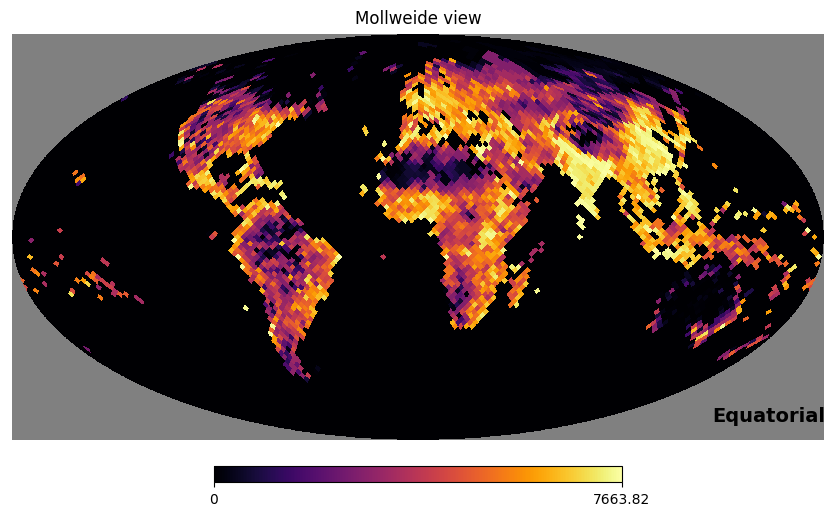

In [15]:
import numpy as np
import healpy as hp
from osgeo import gdal

# Load GeoTIFF image
geotiff_path = '/media/sf_Shared_Ubuntu/MAPS/GPW_2020_1deg.tif'
dataset = gdal.Open(geotiff_path)
data = dataset.ReadAsArray()

# Get geotransformation information
geotransform = dataset.GetGeoTransform()

# Extract geographic bounding box
min_lon = geotransform[0]
max_lat = geotransform[3]
pixel_width = geotransform[1]
pixel_height = geotransform[5]

# Convert latitude to the [0, π] range
theta = np.radians(90.0 - max_lat - np.arange(data.shape[0]) * pixel_height)
theta = np.clip(theta, 0, np.pi)  # Ensure values are within [0, π]

phi = np.radians(np.arange(data.shape[1]) * pixel_width + min_lon)

# Create Healpy map
nside =32   # Choose an appropriate nside value
healpy_map = np.zeros(hp.nside2npix(nside))

# Resample or reproject data and assign values to the Healpy map
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        healpix_index = hp.ang2pix(nside, theta[i], phi[j])
        healpy_map[healpix_index] = data[i, j]

# Visualize or analyze the Healpy map
# ... (use Healpy's visualization and analysis functions)
hp.mollview(healpy_map, cmap="inferno", xsize=3000,coord="c", flip="geo", norm="hist",min=0)
# Save the Healpy map if needed
#hp.write_map('output_healpy_map.fits', healpy_map)
